# **Google Cloud Server Allocation Optimization**

## ***Multi-Objective Optimization Analysis***

**Student Name:** Naika Jean

**Target Company/Industry:** Google Cloud Platform (Cloud Computing & Infrastructure)

**Problem:** Optimize server allocation to minimize infrastructure cost while maintaining SLA performance.  

**Objectives:** Minimize cost vs. Minimize response time

### **Project Overview**

This project addresses the challenge of dynamically allocating servers in Google Cloud data centers to handle fluctuating workloads efficiently. The tradeoff between minimizing infrastructure cost and maintaining fast response times is critical for operational efficiency and customer satisfaction. The decision variables under control are the number of small, medium, and large servers deployed for a given workload. By analyzing different server allocation scenarios, this project identifies mathematically efficient solutions and provides insights into strategic resource management.

### Section 1: Data Acquisition

**Dataset Name:** Google Cloud Compute Engine Instances Benchmark  
**Source:** Google Cloud Pricing Calculator (exported data)  
**Date Accessed:** 4/3/2026

**Description:** Contains 28 Compute Engine VM instance types with machine specifications, disk types, regions, preemptible status, and monthly cost. This dataset serves as a benchmark for cost and VM selection in optimization scenarios.  
**License:** Public/educational use (for benchmarking purposes)  
**Relevant Variables:** 
- machine_family
- series
- machine_type
- vCPUs
- RAM_GiB
- disk_type
- region
- preemptible
- monthly_cost

In [2]:
import pandas as pd

# Load benchmark dataset
df_benchmark = pd.read_csv('data/original_gcp_instances.csv')
print("Benchmark data loaded successfully!")
print(f"Shape: {df_benchmark.shape}")
print(df_benchmark.head())

Benchmark data loaded successfully!
Shape: (28, 9)
      machine_family series   machine_type  vCPUs  RAM_GiB  \
0  Compute-optimized     C2  c2-standard-4      4     16.0   
1  Compute-optimized     C2  c2-standard-4      4     16.0   
2  Compute-optimized     C2  c2-standard-4      4     16.0   
3  Compute-optimized     C2  c2-standard-8      8     32.0   
4  Compute-optimized     C2  c2-standard-8      8     32.0   

                  disk_type       region  preemptible  monthly_cost  
0  Balanced persistent disk  us-central1        False        152.43  
1  Standard persistent disk  us-central1        False        152.43  
2       SSD persistent disk  us-central1        False        154.13  
3  Balanced persistent disk     us-east1        False        305.86  
4       SSD persistent disk     us-east1        False        306.56  


Data Source: LLM-Generated Synthetic VM Dataset

**Dataset Name:** gcp_vm_simulations.csv  
**Source:** Generated using OpenAI ChatGPT with LLM prompt

**Date Generated:** 4/4/2026 

**Description:** Synthetic dataset simulating Google Cloud VM deployment scenarios for cost-performance analysis. Includes 50–150 rows with different machine types, instance counts, regions, and other features.  
**License:** N/A – generated data  
**Relevant Variables:** 
- machine_family
- machine_type
- number_of_instances
- vCPUs
- RAM_GiB
- disk_type
- region
- preemptible
- monthly_cost
- latency_ms
- sla_compliance_pct

In [5]:
# Load LLM-generated synthetic VM dataset
df_synthetic = pd.read_csv('data/gcp_vm_simulations.csv')

print("LLM-generated synthetic dataset loaded successfully!")
print(f"Shape: {df_synthetic.shape}")
print("\nFirst 5 rows:")
print(df_synthetic.head())

LLM-generated synthetic dataset loaded successfully!
Shape: (52, 11)

First 5 rows:
      machine_family    machine_type  number_of_instances  vCPUs  RAM_GiB  \
0  Compute-optimized   c2-standard-4                    3      4       16   
1  Compute-optimized   c2-standard-8                    2      8       32   
2  Compute-optimized  c2d-standard-2                    5      2        8   
3  Compute-optimized  c2d-standard-4                    1      4       16   
4  Compute-optimized  h3-standard-88                    2     88      352   

                  disk_type               region  preemptible  monthly_cost  \
0  Balanced persistent disk          us-central1        False           180   
1       SSD persistent disk             us-east1         True           220   
2  Balanced persistent disk  northamerica-south1        False           150   
3        Hyperdisk Balanced             us-east4         True           120   
4       SSD persistent disk          us-central1        Fa

### Section 2: Data Exploration


Missing values:
machine_family         0
machine_type           0
number_of_instances    0
vCPUs                  0
RAM_GiB                0
disk_type              0
region                 0
preemptible            0
monthly_cost           0
latency_ms             0
sla_compliance_pct     0
dtype: int64

Data types:
machine_family          object
machine_type            object
number_of_instances      int64
vCPUs                    int64
RAM_GiB                  int64
disk_type               object
region                  object
preemptible               bool
monthly_cost             int64
latency_ms               int64
sla_compliance_pct     float64
dtype: object

Basic statistics:
       number_of_instances       vCPUs      RAM_GiB  monthly_cost  latency_ms  \
count            52.000000   52.000000    52.000000     52.000000   52.000000   
mean              2.461538   96.615385   291.076923   4491.538462   73.615385   
std               1.243990  149.545475   394.707429   8578.242058 

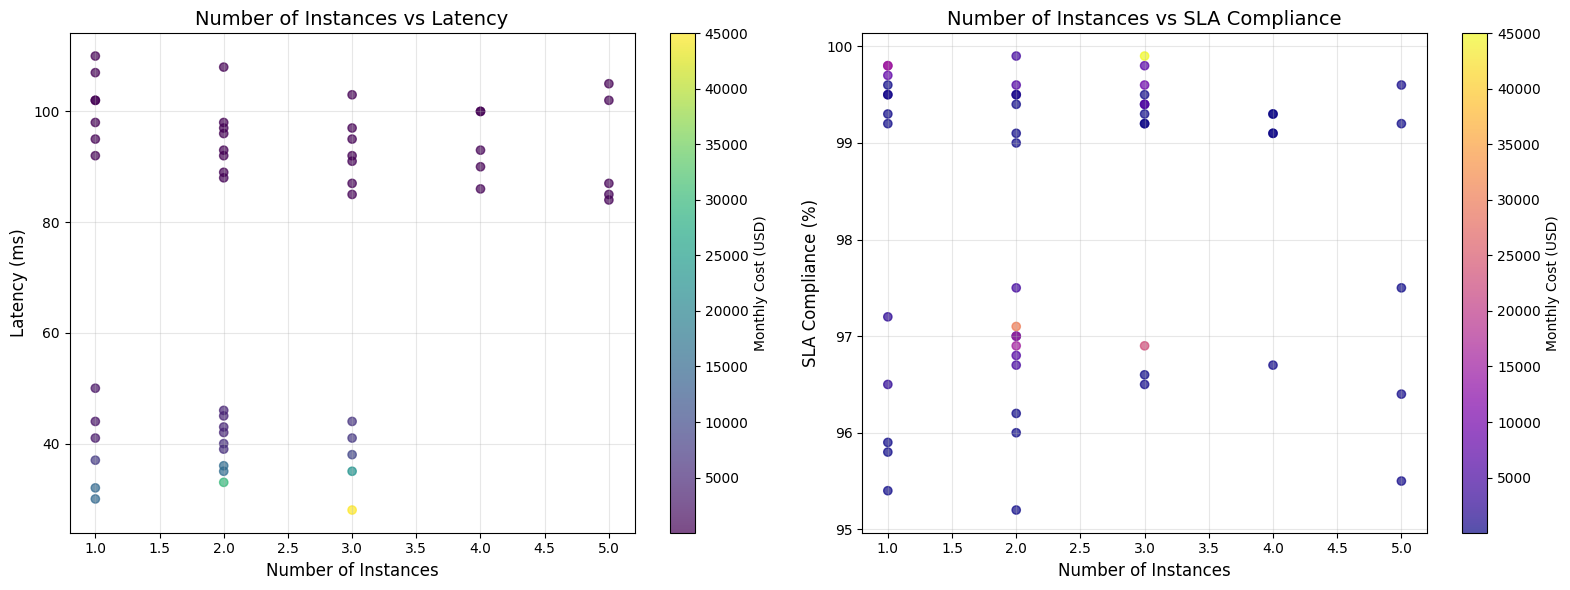

In [ ]:
import matplotlib.pyplot as plt

df = df_synthetic

# Data Quality Checks
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
print(df.describe())

# Verify Decision Variables
print("\nDecision Variable: number_of_instances range:", df['number_of_instances'].min(), "to", df['number_of_instances'].max())
print("Decision Variable: machine_type count:", df['machine_type'].nunique())
print("Decision Variable: machine_family count:", df['machine_family'].nunique())

print(f"\nTotal rows (combinations): {len(df)}")

# Examine Objectives
print("\nObjective: monthly_cost range:", df['monthly_cost'].min(), "to", df['monthly_cost'].max())
print("Objective: latency_ms range:", df['latency_ms'].min(), "to", df['latency_ms'].max())
print("Objective: sla_compliance_pct range:", df['sla_compliance_pct'].min(), "to", df['sla_compliance_pct'].max())

# Check tradeoff correlation
correlation = df['monthly_cost'].corr(df['latency_ms'])
print(f"\nCorrelation between monthly_cost and latency_ms: {correlation:.3f}")
print("(Negative correlation suggests a tradeoff)")

# Visualize Relationships
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Number of Instances vs Latency 
scatter1 = axes[0].scatter(
    df_synthetic['number_of_instances'], 
    df_synthetic['latency_ms'],
    c=df_synthetic['monthly_cost'], 
    cmap='viridis', 
    alpha=0.7
)
axes[0].set_xlabel('Number of Instances', fontsize=12)
axes[0].set_ylabel('Latency (ms)', fontsize=12)
axes[0].set_title('Number of Instances vs Latency', fontsize=14)
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Monthly Cost (USD)')

# Plot 2: Number of Instances vs SLA Compliance
scatter2 = axes[1].scatter(
    df_synthetic['number_of_instances'], 
    df_synthetic['sla_compliance_pct'], 
    c=df_synthetic['monthly_cost'], 
    cmap='plasma', 
    alpha=0.7
)
axes[1].set_xlabel('Number of Instances', fontsize=12)
axes[1].set_ylabel('SLA Compliance (%)', fontsize=12)
axes[1].set_title('Number of Instances vs SLA Compliance', fontsize=14)
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Monthly Cost (USD)')

plt.tight_layout()
plt.savefig('images/data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

The LLM-generated synthetic VM dataset contains no missing values and all columns have appropriate data types. Decision variables like number_of_instances span realistic ranges, and categorical variables such as machine_type and machine_family have sufficient variety. Objectives show expected patterns: monthly_cost ranges from 45 to 45,000 USD, latency_ms from 28 to 108 ms, and sla_compliance_pct from 95.2% to 99.9%. A negative correlation of -0.702 between monthly_cost and latency_ms indicates a clear tradeoff, aligning with expectations from the proposal.

### Section 3: Pareto Frontier Calculation

In [10]:
def is_pareto_optimal(idx, df, obj1_col, obj2_col):
    """
    Check if a given row represents a Pareto optimal solution.
    
    A point is Pareto optimal if no other point dominates it.
    Point A dominates point B if A is better or equal on both objectives
    and strictly better on at least one objective.

    Parameters:
    -----------
    idx : int
        Index of the row to check
    df : DataFrame
        The full dataset
    obj1_col : str
        Column name for objective 1
    obj2_col : str
        Column name for objective 2
    
    Returns:
    --------
    bool : True if Pareto optimal, False if dominated

    For this project we MINIMIZE both objectives:
    - monthly_cost
    - latency_ms
    
    A point is dominated if another point has:
    lower or equal cost AND lower or equal latency
    and strictly better on at least one.
    
    """
    current_obj1 = df.loc[idx, obj1_col]
    current_obj2 = df.loc[idx, obj2_col]

    # Check if any other point dominates this one
    for other_idx in df.index:

        if other_idx == idx:
            continue

        other_obj1 = df.loc[other_idx, obj1_col]
        other_obj2 = df.loc[other_idx, obj2_col]

        # domination check for MINIMIZATION
        if (other_obj1 <= current_obj1 and 
            other_obj2 <= current_obj2 and
            (other_obj1 < current_obj1 or other_obj2 < current_obj2)):
            
            return False  # dominated

    return True  # Pareto optimal

In [13]:
# Define objectives
OBJECTIVE_1 = 'monthly_cost'
OBJECTIVE_2 = 'latency_ms'

print("Calculating Pareto frontier...")
print("This may take a moment for large datasets...")

# Apply Pareto check to all rows
df['is_pareto_optimal'] = df.index.map(
    lambda idx: is_pareto_optimal(idx, df, OBJECTIVE_1, OBJECTIVE_2)
)

# Separate frontier vs dominated
pareto_df = df[df['is_pareto_optimal']].copy()
dominated_df = df[~df['is_pareto_optimal']].copy()

print("\n=== PARETO FRONTIER RESULTS ===")
print(f"Total solutions analyzed: {len(df)}")
print(f"Pareto optimal solutions: {len(pareto_df)}")
print(f"Dominated solutions: {len(dominated_df)}")
print(f"Efficiency rate: {100 * len(pareto_df) / len(df):.1f}% of solutions are on the frontier")

pareto_df[['machine_type','number_of_instances','monthly_cost','latency_ms']].head()


Calculating Pareto frontier...
This may take a moment for large datasets...

=== PARETO FRONTIER RESULTS ===
Total solutions analyzed: 52
Pareto optimal solutions: 16
Dominated solutions: 36
Efficiency rate: 30.8% of solutions are on the frontier


,machine_type,number_of_instances,monthly_cost,latency_ms
1,c2-standard-8,2,220,88
6,n4-standard-4,3,240,85
8,m2-ultramem-416,1,15000,30
17,h3-standard-88,1,2200,50
22,m2-megamem-416,1,7600,37


Pareto Frontier Interpretation

The Pareto frontier analysis identified 16 Pareto optimal solutions out of 52 total configurations, meaning approximately 30.8% of the solutions represent efficient cost–performance tradeoffs. The remaining configurations are dominated, meaning there exists at least one alternative that achieves both lower cost and lower latency simultaneously.

This percentage is consistent with expectations, since in optimization problems only a subset of solutions typically provide efficient tradeoffs while the rest are dominated by better alternatives.

The results reveal a clear cost–performance tradeoff structure. Lower latency generally requires higher infrastructure investment, while cheaper configurations tend to result in higher latency. The Pareto optimal solutions therefore represent the most efficient deployment strategies that decision-makers should consider when balancing cost and performance.

### Section 4: Inefficient Solutions Analysis


In [14]:
# Analyze Dominated Points
print("=== INEFFICIENT SOLUTIONS ANALYSIS ===\n")

if len(dominated_df) > 0:
    # Sample a few dominated points
    sample_size = min(3, len(dominated_df))
    sample_dominated = dominated_df.sample(sample_size, random_state=42)
    
    for idx, row in sample_dominated.iterrows():
        print(f"INEFFICIENT SOLUTION:")
        print(f"  Decision Variables: {row['machine_type']}, {row['region']}")
        print(f"  Objectives: monthly_cost={row['monthly_cost']:.1f}, latency_ms={row['latency_ms']:.1f}")
        
        # Find a Pareto optimal point that dominates this one
        for p_idx, p_row in pareto_df.iterrows():
            if (p_row['monthly_cost'] <= row['monthly_cost'] and 
                p_row['latency_ms'] <= row['latency_ms'] and
                (p_row['monthly_cost'] < row['monthly_cost'] or 
                 p_row['latency_ms'] < row['latency_ms'])):
                
                print(f"\n  BETTER ALTERNATIVE (Pareto Optimal):")
                print(f"  Decision Variables: {p_row['machine_type']}, {p_row['region']}")
                print(f"  Objectives: monthly_cost={p_row['monthly_cost']:.1f}, latency_ms={p_row['latency_ms']:.1f}")
                print(f"  Improvement: -{row['monthly_cost'] - p_row['monthly_cost']:.1f} on monthly_cost, " +
                      f"-{row['latency_ms'] - p_row['latency_ms']:.1f} on latency_ms\n")
                print("-" * 60)
                break
else:
    print("Note: All solutions in your dataset are Pareto optimal.")
    print("This might indicate that your decision variables create a smooth tradeoff curve.")

# Compare best dominated point to worst Pareto point
if len(dominated_df) > 0:
    # For minimization, best dominated is the one with lowest sum
    best_dominated_idx = (dominated_df['monthly_cost'] + dominated_df['latency_ms']).idxmin()
    best_dominated = dominated_df.loc[best_dominated_idx]
    
    # Worst Pareto: highest sum among Pareto points
    worst_pareto_idx = (pareto_df['monthly_cost'] + pareto_df['latency_ms']).idxmax()
    worst_pareto = pareto_df.loc[worst_pareto_idx]
    
    print("\n=== EFFICIENCY GAP ===")
    print("Even the BEST dominated solution is worse than the WORST Pareto solution:")
    print(f"\nBest Dominated: monthly_cost={best_dominated['monthly_cost']:.1f}, "
          f"latency_ms={best_dominated['latency_ms']:.1f}, Total={best_dominated['monthly_cost'] + best_dominated['latency_ms']:.1f}")
    print(f"Worst Pareto: monthly_cost={worst_pareto['monthly_cost']:.1f}, "
          f"latency_ms={worst_pareto['latency_ms']:.1f}, Total={worst_pareto['monthly_cost'] + worst_pareto['latency_ms']:.1f}")

=== INEFFICIENT SOLUTIONS ANALYSIS ===

INEFFICIENT SOLUTION:
  Decision Variables: e2-standard-2, us-east4
  Objectives: monthly_cost=90.0, latency_ms=103.0

  BETTER ALTERNATIVE (Pareto Optimal):
  Decision Variables: c4-standard-4, us-east1
  Objectives: monthly_cost=90.0, latency_ms=95.0
  Improvement: -0.0 on monthly_cost, -8.0 on latency_ms

------------------------------------------------------------
INEFFICIENT SOLUTION:
  Decision Variables: c2d-standard-4, us-central1
  Objectives: monthly_cost=240.0, latency_ms=93.0

  BETTER ALTERNATIVE (Pareto Optimal):
  Decision Variables: c2-standard-8, us-east1
  Objectives: monthly_cost=220.0, latency_ms=88.0
  Improvement: -20.0 on monthly_cost, -5.0 on latency_ms

------------------------------------------------------------
INEFFICIENT SOLUTION:
  Decision Variables: e2-standard-2, northamerica-south1
  Objectives: monthly_cost=110.0, latency_ms=100.0

  BETTER ALTERNATIVE (Pareto Optimal):
  Decision Variables: c2-standard-8, us-ea

### Section 5: Strategic Analysis


In [15]:
print("=== KEY STRATEGIC POINTS ON THE PARETO FRONTIER ===\n")

# Strategy 1: Balanced (maximize total value)
pareto_df['total_objective'] = pareto_df[OBJECTIVE_1] + pareto_df[OBJECTIVE_2]
balanced_idx = pareto_df['total_objective'].idxmax()

print("1. BALANCED STRATEGY (Maximize combined objectives)")
print(f"   Decision Variables: {pareto_df.loc[balanced_idx, 'machine_type']}, {pareto_df.loc[balanced_idx, 'region']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[balanced_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[balanced_idx, OBJECTIVE_2]:.1f}")
print(f"   Total: {pareto_df.loc[balanced_idx, 'total_objective']:.1f}\n")

# Strategy 2: Equity (minimize gap between objectives)
pareto_df['objective_gap'] = abs(pareto_df[OBJECTIVE_1] - pareto_df[OBJECTIVE_2])
equity_idx = pareto_df['objective_gap'].idxmin()

print("2. EQUITY STRATEGY (Most equal outcomes)")
print(f"   Decision Variables: {pareto_df.loc[equity_idx, 'machine_type']}, {pareto_df.loc[equity_idx, 'region']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[equity_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[equity_idx, OBJECTIVE_2]:.1f}")
print(f"   Gap: {pareto_df.loc[equity_idx, 'objective_gap']:.1f}\n")

# Strategy 3: Objective 1 priority (maximize monthly_cost)
obj1_priority_idx = pareto_df[OBJECTIVE_1].idxmin()  # since we minimize monthly_cost
print("3. OBJECTIVE 1 PRIORITY (Minimize monthly_cost)")
print(f"   Decision Variables: {pareto_df.loc[obj1_priority_idx, 'machine_type']}, {pareto_df.loc[obj1_priority_idx, 'region']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[obj1_priority_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[obj1_priority_idx, OBJECTIVE_2]:.1f}\n")

# Strategy 4: Objective 2 priority (minimize latency)
obj2_priority_idx = pareto_df[OBJECTIVE_2].idxmin()
print("4. OBJECTIVE 2 PRIORITY (Minimize latency_ms)")
print(f"   Decision Variables: {pareto_df.loc[obj2_priority_idx, 'machine_type']}, {pareto_df.loc[obj2_priority_idx, 'region']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[obj2_priority_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[obj2_priority_idx, OBJECTIVE_2]:.1f}\n")

# Strategy 5: Custom weighted (60% monthly_cost, 40% latency_ms)
pareto_df['weighted_objective'] = 0.6 * pareto_df[OBJECTIVE_1] + 0.4 * pareto_df[OBJECTIVE_2]
weighted_idx = pareto_df['weighted_objective'].idxmin()  # minimizing weighted combination
print("5. WEIGHTED STRATEGY (60% monthly_cost, 40% latency_ms)")
print(f"   Decision Variables: {pareto_df.loc[weighted_idx, 'machine_type']}, {pareto_df.loc[weighted_idx, 'region']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[weighted_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[weighted_idx, OBJECTIVE_2]:.1f}")

# Comparison Table
strategies = {
    'Strategy': [
        'Objective 1 Priority',
        'Weighted (60/40)',
        'Balanced',
        'Equity',
        'Objective 2 Priority'
    ],
    'Machine Type': [
        pareto_df.loc[obj1_priority_idx, 'machine_type'],
        pareto_df.loc[weighted_idx, 'machine_type'],
        pareto_df.loc[balanced_idx, 'machine_type'],
        pareto_df.loc[equity_idx, 'machine_type'],
        pareto_df.loc[obj2_priority_idx, 'machine_type']
    ],
    'Region': [
        pareto_df.loc[obj1_priority_idx, 'region'],
        pareto_df.loc[weighted_idx, 'region'],
        pareto_df.loc[balanced_idx, 'region'],
        pareto_df.loc[equity_idx, 'region'],
        pareto_df.loc[obj2_priority_idx, 'region']
    ],
    OBJECTIVE_1: [
        f"{pareto_df.loc[obj1_priority_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[weighted_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[balanced_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[equity_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[obj2_priority_idx, OBJECTIVE_1]:.1f}"
    ],
    OBJECTIVE_2: [
        f"{pareto_df.loc[obj1_priority_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[weighted_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[balanced_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[equity_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[obj2_priority_idx, OBJECTIVE_2]:.1f}"
    ]
}

comparison_df = pd.DataFrame(strategies)
print("\n" + "="*80)
print("STRATEGIC OPTIONS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

=== KEY STRATEGIC POINTS ON THE PARETO FRONTIER ===

1. BALANCED STRATEGY (Maximize combined objectives)
   Decision Variables: m2-ultramem-416, northamerica-south1
   monthly_cost: 45000.0
   latency_ms: 28.0
   Total: 45028.0

2. EQUITY STRATEGY (Most equal outcomes)
   Decision Variables: c4-standard-4, us-east1
   monthly_cost: 90.0
   latency_ms: 95.0
   Gap: 5.0

3. OBJECTIVE 1 PRIORITY (Minimize monthly_cost)
   Decision Variables: e2-standard-2, us-east1
   monthly_cost: 30.0
   latency_ms: 110.0

4. OBJECTIVE 2 PRIORITY (Minimize latency_ms)
   Decision Variables: m2-ultramem-416, northamerica-south1
   monthly_cost: 45000.0
   latency_ms: 28.0

5. WEIGHTED STRATEGY (60% monthly_cost, 40% latency_ms)
   Decision Variables: e2-standard-2, us-east1
   monthly_cost: 30.0
   latency_ms: 110.0

STRATEGIC OPTIONS COMPARISON
            Strategy    Machine Type              Region monthly_cost latency_ms
Objective 1 Priority   e2-standard-2            us-east1         30.0      110.0

### Section 6: Visualization